We are interested in the confidence interal of the Monte Carlo method used in task 5. We know that the true value of the estimate is $z = \int_0^\pi sin(x) dx = 2.$ We are estimating this value by the sum of $n$ samples from a uniform distribution in the interval $(0,\pi)$, so we can use the central limit theorem to approximate the distribution of the estimate. The expectaion of a sample is:
$$
E[f(X)] = \int_0^\pi sin(x)\frac{1}{\pi}  \iff I = \int_0^\pi sin(x) dx = \pi E[f(X)]
$$
We have the estimator
$$ \hat{I} = \dfrac{\pi}{n}\sum_i^n f(X) = \pi\bar{Z}$$
and by the central limit theorem, we have that
$$\sqrt{n}( \pi\bar{Z} - I) \xrightarrow[]{d} N(0,\sigma^2\pi^2),$$
so
$$ \dfrac{\sqrt{n}( \pi\bar{Z} - I)}{\sigma\pi} \xrightarrow[]{d} N(0,1)$$
Thus, we can construct a confidence interval for the estimate of the integral using the normal distribution. The confidence interval is given by:
$$
CI = (\pi\bar{Z} - 1.96 \frac{\pi s}{\sqrt{n}}, \pi\bar{Z} + 1.96 \frac{\pi s}{\sqrt{n}}) = (\hat{I} - 1.96 \frac{\pi s}{\sqrt{n}}, \hat{I} + 1.96 \frac{\pi s}{\sqrt{n}})
$$
where $s$ is the sample standard deviation.

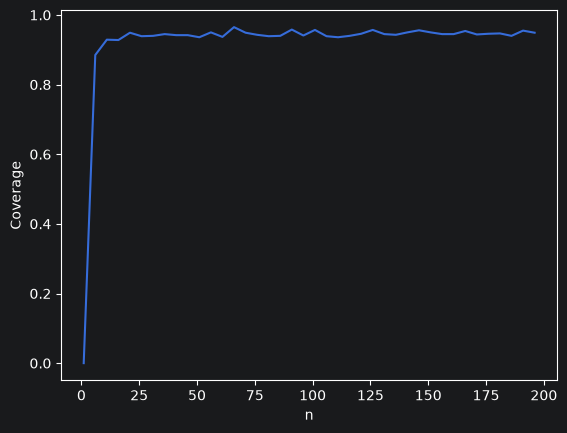

In [2]:
import numpy as np
from task4 import monte_carlo
import matplotlib.pyplot as plt
N = 1000
true_value = 2
ns = range(1, 200, 5)
def simulation(n = 10, N = 1000):
    f = lambda x: np.sin(x)
    i = 0
    for _ in range(N):
        # generate sample X of size n
        x = np.random.uniform(0, np.pi, n)
        z = f(x)
        i_hat = monte_carlo(f, n, 0, np.pi)
        sigma_hat = np.std(z)

        se_hat = np.pi * sigma_hat / np.sqrt(n)

        lower = i_hat - 1.96 * se_hat
        upper = i_hat + 1.96 * se_hat

        if lower <= 2 <= upper:
            i += 1
    coverage = i / N
    return coverage
coverages = []
for n in ns:
    coverages.append(simulation(n))

plt.plot(ns, coverages)
plt.xlabel('n')
plt.ylabel('Coverage')
plt.show()




